# Notebook 04 — Layer 2B Experiments
Train XGBoost, 1D CNN, and GRU. Compare on macro-F1 and per-class F1. Export winner to ONNX.

> Use GPU runtime in Colab for CNN and GRU training.

In [3]:
# ── Mount Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)
os.chdir(PROJECT)
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [2]:
%%capture
!pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [3]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl --ignore-installed blinker

In [4]:
%%capture
!pip install onnxscript

In [2]:
%%capture
!pip uninstall -y numpy scipy scikit-learn xgboost
!pip install --no-cache-dir numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2 xgboost==2.1.1

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.11.4
Uninstalling scipy-1.11.4:
  Successfully uninstalled scipy-1.11.4
Found existing installation: scikit-learn 1.4.2
Uninstalling scikit-learn-1.4.2:
  Successfully uninstalled scikit-learn-1.4.2
Found existing installation: xgboost 2.1.1
Uninstalling xgboost-2.1.1:
  Successfully uninstalled xgboost-2.1.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 145.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 305.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 186.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 235.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 234.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 211.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take int

In [1]:
import numpy as np
import scipy
import sklearn
import xgboost

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

numpy: 1.26.4
scipy: 1.11.4
sklearn: 1.4.2
xgboost: 2.1.1


In [4]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import mlflow
from pathlib import Path

from layer2b.candidates.xgboost_model import XGBoostModel
from layer2b.candidates.cnn_1d import CNN1DModel
from layer2b.candidates.gru import GRUModel
from layer2b.evaluate import evaluate_candidate, pick_best
from evaluation.compare_models import compare_l2b, pick_best_l2b
from evaluation.benchmark import benchmark_xgboost, benchmark_cnn_1d, benchmark_gru

SPLITS  = Path("../data/splits")
EXPORTS = Path("../exported_models")
EXPORTS.mkdir(exist_ok=True)

CLASS_NAMES = ["normal", "sqli", "xss", "lfi", "other_attack"]

mlflow.set_experiment("layer2b")

<Experiment: artifact_location='/content/drive/MyDrive/waf-ml-project/ml/mlruns/2', creation_time=1774848422739, experiment_id='2', last_update_time=1774848422739, lifecycle_stage='active', name='layer2b', tags={}, workspace='default'>

## 1. Load splits

In [5]:
import json as _json

X_tr_num  = np.load(SPLITS / "l2b_train_X_numeric.npy")
X_v_num   = np.load(SPLITS / "l2b_val_X_numeric.npy")
X_te_num  = np.load(SPLITS / "l2b_test_X_numeric.npy")

X_tr_tok  = np.load(SPLITS / "l2b_train_X_tokens.npy")
X_v_tok   = np.load(SPLITS / "l2b_val_X_tokens.npy")
X_te_tok  = np.load(SPLITS / "l2b_test_X_tokens.npy")

y_tr = np.load(SPLITS / "l2b_train_y.npy")
y_v  = np.load(SPLITS / "l2b_val_y.npy")
y_te = np.load(SPLITS / "l2b_test_y.npy")

# Load class weights saved by NB01 balance cell
weights_path = Path("../data/processed/class_weights.json")
if weights_path.exists():
    with open(weights_path) as f:
        wt_data = _json.load(f)
    print("Class weights loaded:")
    for cls, w in wt_data["weights_dict"].items():
        print(f"  {cls:<15}: {w:.4f}")
else:
    print("⚠️  class_weights.json not found — using uniform weights")
    wt_data = None

print(f"\nTrain: {X_tr_num.shape}")
print(f"  classes: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"Val:   {X_v_num.shape}")
print(f"Test:  {X_te_num.shape}")


Class weights loaded:
  normal         : 0.5733
  sqli           : 1.4311
  xss            : 2.1568
  lfi            : 0.9555
  other_attack   : 0.9555

Train: (10032, 25)
  classes: {0: 3500, 1: 1402, 2: 930, 3: 2100, 4: 2100}
Val:   (2150, 25)
Test:  (2150, 25)


## 2. Candidate 1 — XGBoost (numeric features, CPU)

In [6]:
xgb = XGBoostModel()
xgb.train(X_tr_num, y_tr, X_v_num, y_v)
res_xgb = evaluate_candidate(xgb, X_te_num, y_te, name="xgboost")


[0]	validation_0-mlogloss:1.51681
[100]	validation_0-mlogloss:0.17346
[200]	validation_0-mlogloss:0.11982
[300]	validation_0-mlogloss:0.10544
[400]	validation_0-mlogloss:0.10191
[499]	validation_0-mlogloss:0.10120
[XGB] Best iter=480  val_f1=0.9662  val_acc=0.9614

[evaluate] xgboost
              precision    recall  f1-score   support

      normal       0.94      0.97      0.95       750
        sqli       0.99      1.00      0.99       301
         xss       0.96      0.93      0.95       199
         lfi       0.98      1.00      0.99       450
other_attack       0.94      0.87      0.90       450

    accuracy                           0.95      2150
   macro avg       0.96      0.95      0.96      2150
weighted avg       0.95      0.95      0.95      2150



### XGBoost feature importance

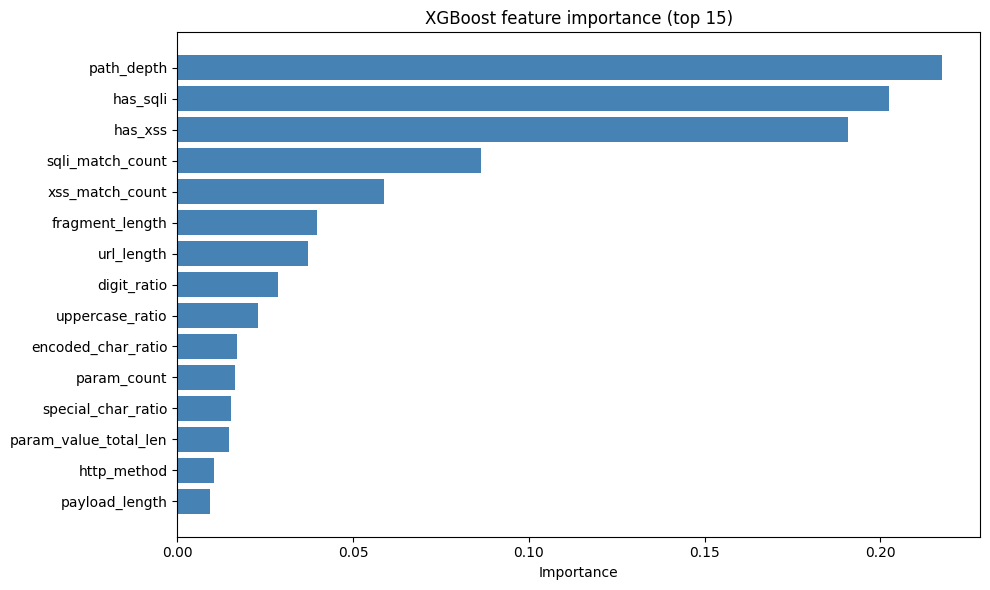

In [7]:
from feature_engineering.extractor import FEATURE_NAMES
import matplotlib.pyplot as plt

fi = xgb.feature_importance(FEATURE_NAMES)
plt.figure(figsize=(10, 6))
plt.barh(list(fi.keys())[:15], list(fi.values())[:15], color="steelblue")
plt.xlabel("Importance")
plt.title("XGBoost feature importance (top 15)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../data/processed/04_xgb_feature_importance.png", dpi=120)
plt.show()

## 3. Candidate 2 — 1D CNN (character sequences, GPU)

In [8]:
cnn = CNN1DModel()
cnn.train(X_tr_tok, y_tr, X_v_tok, y_v)
res_cnn = evaluate_candidate(cnn, X_te_tok, y_te, name="cnn_1d")

[CNN1D] Training on cuda
  epoch   5 | loss=0.0562 | val_f1=0.9903 | val_acc=0.9898
  epoch  10 | loss=0.0275 | val_f1=0.9941 | val_acc=0.9940
  epoch  15 | loss=0.0161 | val_f1=0.9931 | val_acc=0.9935
[CNN1D] Early stopping at epoch 19
[CNN1D] Best val F1: 0.9948

[evaluate] cnn_1d
              precision    recall  f1-score   support

      normal       0.99      0.99      0.99       750
        sqli       1.00      1.00      1.00       301
         xss       0.99      0.96      0.98       199
         lfi       0.99      1.00      1.00       450
other_attack       0.98      0.98      0.98       450

    accuracy                           0.99      2150
   macro avg       0.99      0.99      0.99      2150
weighted avg       0.99      0.99      0.99      2150



## 4. Candidate 3 — GRU (character sequences, GPU)

In [9]:
gru = GRUModel()
gru.train(X_tr_tok, y_tr, X_v_tok, y_v)
res_gru = evaluate_candidate(gru, X_te_tok, y_te, name="gru")

[GRU] Training on cuda
  epoch   5 | loss=0.2494 | val_f1=0.9162 | val_acc=0.9107
  epoch  10 | loss=0.0509 | val_f1=0.9874 | val_acc=0.9879
  epoch  15 | loss=0.0420 | val_f1=0.9863 | val_acc=0.9879
  epoch  20 | loss=0.0193 | val_f1=0.9920 | val_acc=0.9926
  epoch  25 | loss=0.0085 | val_f1=0.9927 | val_acc=0.9940
  epoch  30 | loss=0.0061 | val_f1=0.9927 | val_acc=0.9940
  epoch  35 | loss=0.0031 | val_f1=0.9929 | val_acc=0.9935
[GRU] Early stopping at epoch 35
[GRU] Best val F1: 0.9936

[evaluate] gru
              precision    recall  f1-score   support

      normal       0.99      1.00      1.00       750
        sqli       1.00      1.00      1.00       301
         xss       0.99      0.98      0.99       199
         lfi       1.00      1.00      1.00       450
other_attack       0.99      0.99      0.99       450

    accuracy                           0.99      2150
   macro avg       0.99      0.99      0.99      2150
weighted avg       0.99      0.99      0.99      2150



## 5. Compare all candidates

In [10]:
all_results = [res_xgb, res_cnn, res_gru]
df_compare = compare_l2b(all_results)
df_compare


=== Layer 2B Model Comparison ===
  Model  Macro F1  Accuracy  F1 (normal)  F1 (sqli)  F1 (xss)  F1 (lfi)  F1 (other_attack)
    gru    0.9936    0.9944       0.9960     0.9967    0.9873    0.9978             0.9900
 cnn_1d    0.9886    0.9893       0.9907     0.9983    0.9796    0.9956             0.9789
xgboost    0.9561    0.9549       0.9534     0.9917    0.9466    0.9879             0.9009


,Model,Macro F1,Accuracy,F1 (normal),F1 (sqli),F1 (xss),F1 (lfi),F1 (other_attack)
2,gru,0.9936,0.9944,0.9960,0.9967,0.9873,0.9978,0.9900
1,cnn_1d,0.9886,0.9893,0.9907,0.9983,0.9796,0.9956,0.9789
0,xgboost,0.9561,0.9549,0.9534,0.9917,0.9466,0.9879,0.9009


## 6. Pick winner and export ONNX

In [11]:
import json as _json

all_models = {"xgboost": xgb, "cnn_1d": cnn, "gru": gru}
winner_name, winner_model = pick_best_l2b(all_results, all_models)
print(f"Winner: {winner_name}")

onnx_path = str(EXPORTS / "layer2b_best.onnx")
winner_model.export_onnx(onnx_path)

# FIX: save results JSON so NB05 can load real results instead of hardcoded values
results_path = EXPORTS / "l2b_results.json"
with open(results_path, "w") as f:
    _json.dump({"results": all_results, "winner": winner_name}, f, indent=2)
print(f"Results saved → {results_path}")



[compare] L2B Winner: gru  Macro F1=0.9936  Accuracy=0.9944
Winner: gru


/content/drive/MyDrive/waf-ml-project/ml/layer2b/candidates/gru.py:262: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0401 19:36:06.559000 12783 usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `GRUClassifier([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.gru._flat_weights[0], self.gru._flat_weights[1], self.gru._flat_weights[2], self.gru._flat_weights[3], self.gru._flat_weights[4], self.gru._flat_weights[5], self.gru._flat_weights[6], self.gru._flat_weights[7], self.gru._flat_weights[8], self.gru._flat_weights[9], self.gru._flat_weights[10], self.gru._flat_weights[11], self.gru._flat_weights[12], self.gru._flat_weights[13], self.gru._flat_weights[14], self.gru._flat_weights[15] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `GRUClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 1 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
[GRU] ONNX exported → ../exported_models/layer2b_best.onnx
[GRU] avg=11.02ms  p99=16.737ms  PASS
Results saved → ../exported_models/l2b_results.json


## 7. Confusion matrices — all models

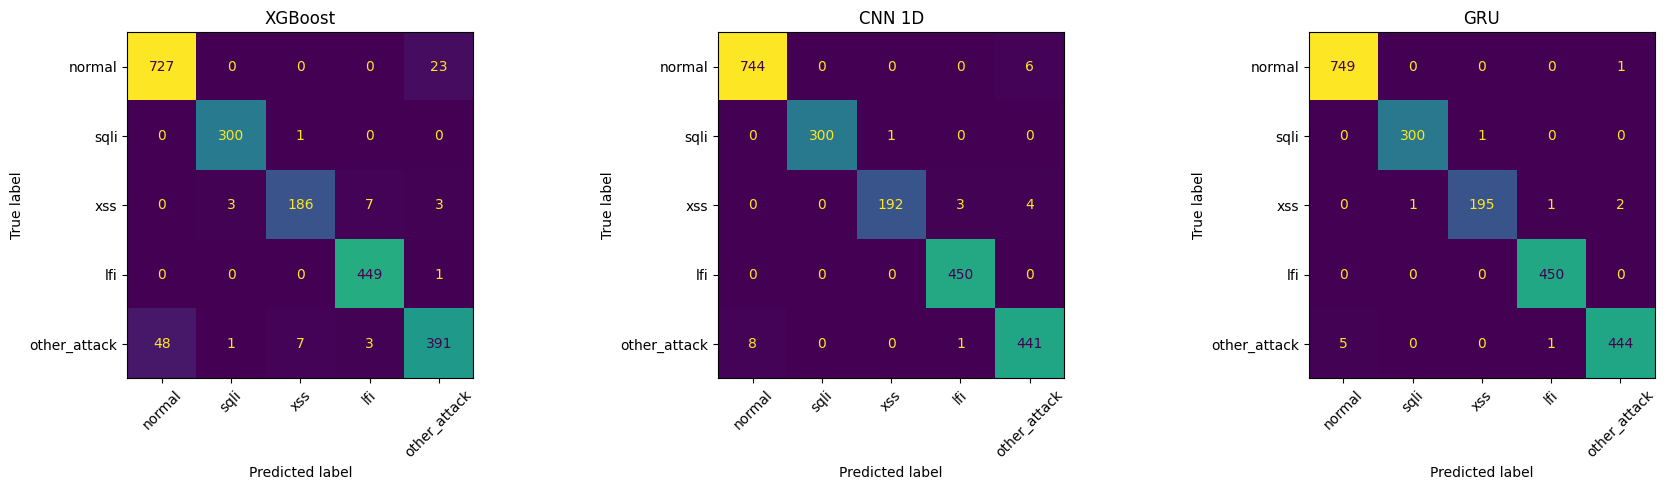

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model, X_te_input) in zip(axes, [
    ("XGBoost",  xgb, X_te_num),
    ("CNN 1D",   cnn, X_te_tok),
    ("GRU",      gru, X_te_tok),
]):
    preds = model.predict(X_te_input)
    cm    = confusion_matrix(y_te, preds, labels=list(range(5)))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../data/processed/04_confusion_matrices.png", dpi=120)
plt.show()

## 8. GRU attention visualisation (single anomalous request)

In [13]:
from feature_engineering.tokenizer import CharTokenizer

tok = CharTokenizer()

# Pick one attack sample from each class for attention analysis
print("=== GRU Attention Map — Explainability Demo ===")
print("Shows which characters the model focuses on when classifying an attack.\n")

CLASS_NAMES_L = ["normal", "sqli", "xss", "lfi", "other_attack"]

for target_class in [1, 2, 3, 4]:   # sqli, xss, lfi, other_attack
    class_indices = np.where(y_te == target_class)[0]
    if len(class_indices) == 0:
        continue
    attack_idx = class_indices[0]
    token_ids  = X_te_tok[attack_idx:attack_idx+1]
    char_weights = gru.attention_map(token_ids, tok)

    cls_name = CLASS_NAMES_L[target_class]
    print(f"--- {cls_name.upper()} sample ---")
    # Reconstruct text from token ids
    text = tok.decode(token_ids[0])[:80]
    print(f"  Request: {text}")

    # Show top 10 highest-attention chars (skip URL structure chars q, ?, =, /)
    skip = set(' qQ?=/&+GET POST')
    meaningful = [(ch, w) for ch, w in char_weights
                  if ch not in skip and w > 0.001]
    top10 = sorted(meaningful, key=lambda x: x[1], reverse=True)[:10]
    print(f"  Top attention characters (excluding URL structure):")
    for ch, w in top10:
        bar = "█" * min(int(w * 300), 40)
        print(f"    '{ch}'  {bar}  ({w:.4f})")
    print()


=== GRU Attention Map — Explainability Demo ===
Shows which characters the model focuses on when classifying an attack.

--- SQLI sample ---
  Request: GET http://localhost:8080/tienda1/publico/entrar.jsp?errorMsg=%27%3Bwaitfor+dela
  Top attention characters (excluding URL structure):
    '2'  ████████████████████████  (0.0827)
    '3'  ███████████████████  (0.0638)
    '7'  ██████████████████  (0.0625)
    'A'  █████████████████  (0.0585)
    'A'  █████████████████  (0.0585)
    '3'  ████████████████  (0.0560)
    '%'  ███████████████  (0.0515)
    '%'  █████████████  (0.0460)
    '2'  ███████████  (0.0400)
    '0'  ███████████  (0.0388)

--- XSS sample ---
  Request: GET /?input={/* if user controls props spread */} nan
  Top attention characters (excluding URL structure):
    '{'  ████████████████████████████████████████  (0.2446)
    't'  ██████████████  (0.0476)
    '*'  █████████████  (0.0436)
    'd'  ███████  (0.0237)
    'u'  ███  (0.0109)
    'a'  █  (0.0045)
    'p'    (0.0